# Fit ANN Initialization Parameters (No Prior)

This notebook estimates ANN initialization parameters for the reduced oxygen-only decision network.

Assumptions used from the paper (behavioral rules):
- apoptosis when oxygen is below a hypoxia threshold;
- quiescence under contact inhibition (`n > 3` neighbors);
- proliferation otherwise.

Important setup choice:
- **no parameter prior is used**;
- parameters are fit from scratch via multi-start optimization;
- objective is to reproduce the paper-defined decision behavior on a `(c, n)` grid.

Output:
- `ann_init_fitted_params.json` in the `simulation/` folder.


In [19]:
from __future__ import annotations

import json
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
from scipy.optimize import minimize


In [20]:
# --- Fit configuration ---

# Paper-inspired behavioral thresholds for the reduced model.
# Oxygen is normalized to [0, 1], so 0.15 means 15% of boundary oxygen.
OXYGEN_APOPTOSIS_THRESHOLD = 0.15
CONTACT_INHIBITION_THRESHOLD = 3

# Input domain sampled for fitting.
C_MIN = 0.0
C_MAX = 1.0
N_MIN = 0
N_MAX = 8
N_C_SAMPLES = 401

# Multi-start optimization from random initializations.
N_RESTARTS = 40
SEED = 11
MAXITER = 2500

# Small non-prior weight decay to avoid unbounded logits on separable targets.
L2_WEIGHT_DECAY = 1e-4

# Random initialization ranges for raw (interpretable) parameters.
INIT_RANGES = {
    "k_n": (0.1, 30.0),
    "k_c": (0.1, 60.0),
    "sN": (0.1, 25.0),
    "sA": (0.01, 25.0),
    "sAA": (0.1, 30.0),
    "bP": (-12.0, 12.0),
    "bQ": (-12.0, 12.0),
    "bA": (-12.0, 12.0),
}


def resolve_sim_dir() -> Path:
    # Resolve the simulation directory from common execution paths.
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "simulation",
        cwd / "Hybrid-Cellular-Automata" / "simulation",
    ]
    for c in candidates:
        if (c / "model.py").exists() and (c / "utils.py").exists():
            return c
    raise FileNotFoundError("Could not resolve the simulation directory")


SIM_DIR = resolve_sim_dir()
OUT_JSON = SIM_DIR / "ann_init_fitted_params.json"
SIM_DIR, OUT_JSON


(PosixPath('/Users/gianlucapanzani/Desktop/Informatica Computer Science/CMCS clone repo/Hybrid-Cellular-Automata/simulation'),
 PosixPath('/Users/gianlucapanzani/Desktop/Informatica Computer Science/CMCS clone repo/Hybrid-Cellular-Automata/simulation/ann_init_fitted_params.json'))

In [21]:
# --- Reduced ANN parameterization (same structure as model.py) ---


def transfer_sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-2.0 * x))


def softplus(x: np.ndarray) -> np.ndarray:
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)


def inv_softplus(y: float) -> float:
    # Valid for y > 0.
    return float(np.log(np.expm1(y)))


@dataclass
class RawParams:
    # Positive parameters (optimized in unconstrained space via softplus).
    k_n: float
    k_c: float
    sN: float
    sA: float
    sAA: float

    # Unconstrained biases.
    bP: float
    bQ: float
    bA: float


def pack_unconstrained(p: RawParams) -> np.ndarray:
    return np.array(
        [
            inv_softplus(p.k_n),
            inv_softplus(p.k_c),
            inv_softplus(p.sN),
            inv_softplus(p.sA),
            inv_softplus(p.sAA),
            p.bP,
            p.bQ,
            p.bA,
        ],
        dtype=np.float64,
    )


def unpack_unconstrained(u: np.ndarray) -> RawParams:
    return RawParams(
        k_n=float(softplus(u[0]) + 1e-10),
        k_c=float(softplus(u[1]) + 1e-10),
        sN=float(softplus(u[2]) + 1e-10),
        sA=float(softplus(u[3]) + 1e-10),
        sAA=float(softplus(u[4]) + 1e-10),
        bP=float(u[5]),
        bQ=float(u[6]),
        bA=float(u[7]),
    )


def random_raw_params(rng: np.random.Generator) -> RawParams:
    # Sample one random initialization in raw parameter space.
    return RawParams(
        k_n=float(rng.uniform(*INIT_RANGES["k_n"])),
        k_c=float(rng.uniform(*INIT_RANGES["k_c"])),
        sN=float(rng.uniform(*INIT_RANGES["sN"])),
        sA=float(rng.uniform(*INIT_RANGES["sA"])),
        sAA=float(rng.uniform(*INIT_RANGES["sAA"])),
        bP=float(rng.uniform(*INIT_RANGES["bP"])),
        bQ=float(rng.uniform(*INIT_RANGES["bQ"])),
        bA=float(rng.uniform(*INIT_RANGES["bA"])),
    )


def logits_pqa(u: np.ndarray, c: np.ndarray, n: np.ndarray) -> np.ndarray:
    # Compute P/Q/A logits for the reduced ANN architecture.
    p = unpack_unconstrained(u)

    # Hidden gates.
    h_n = transfer_sigmoid(p.k_n * n - p.k_n * CONTACT_INHIBITION_THRESHOLD)
    h_a = transfer_sigmoid(-p.k_c * c + p.k_c * OXYGEN_APOPTOSIS_THRESHOLD)

    # Output pre-activations.
    z_p = -p.sN * h_n - p.sA * h_a + p.bP
    z_q = +p.sN * h_n - p.sA * h_a + p.bQ
    z_a = +p.sAA * h_a - p.bA

    return np.stack([z_p, z_q, z_a], axis=1)


In [22]:
# --- Target dataset from paper-defined behavior ---
# Rule:
#   if c < OXYGEN_APOPTOSIS_THRESHOLD -> A
#   elif n > CONTACT_INHIBITION_THRESHOLD -> Q
#   else -> P

c_values = np.linspace(C_MIN, C_MAX, N_C_SAMPLES)
n_values = np.arange(N_MIN, N_MAX + 1, dtype=np.float64)

C_grid, N_grid = np.meshgrid(c_values, n_values, indexing="xy")
C = C_grid.ravel()
N = N_grid.ravel()

# Labels: P=0, Q=1, A=2
Y = np.where(
    C < OXYGEN_APOPTOSIS_THRESHOLD,
    2,
    np.where(N > CONTACT_INHIBITION_THRESHOLD, 1, 0),
).astype(np.int64)

C.shape, N.shape, Y.shape


((3609,), (3609,), (3609,))

In [23]:
# --- Objective and metrics ---
# No parameter prior is used. A small L2 penalty on parameter magnitude is added
# only to avoid coefficient blow-up on perfectly separable targets.


def logsumexp(x: np.ndarray, axis: int = -1, keepdims: bool = False) -> np.ndarray:
    m = np.max(x, axis=axis, keepdims=True)
    y = m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True))
    return y if keepdims else np.squeeze(y, axis=axis)


def loss_fn(u: np.ndarray) -> float:
    z = logits_pqa(u, C, N)
    lse = logsumexp(z, axis=1, keepdims=False)
    ce = float(np.mean(lse - z[np.arange(z.shape[0]), Y]))
    wd = float(L2_WEIGHT_DECAY * np.mean(u ** 2))
    return ce + wd


def accuracy_fn(u: np.ndarray) -> float:
    z = logits_pqa(u, C, N)
    pred = np.argmax(z, axis=1)
    return float(np.mean(pred == Y))


In [24]:
# --- Multi-start fitting from random initializations ---
rng = np.random.default_rng(SEED)

best = None
results = []

for restart in range(N_RESTARTS):
    u0 = pack_unconstrained(random_raw_params(rng))

    res = minimize(
        loss_fn,
        u0,
        method="L-BFGS-B",
        options={"maxiter": MAXITER, "ftol": 1e-12, "gtol": 1e-8},
    )

    rec = {
        "restart": int(restart),
        "success": bool(res.success),
        "status": int(res.status),
        "message": str(res.message),
        "loss": float(res.fun),
        "acc": float(accuracy_fn(res.x)),
        "nit": int(res.nit),
    }
    results.append(rec)

    if best is None or res.fun < best["res"].fun:
        best = {"res": res, "record": rec}

best["record"], results[:5]


({'restart': 2,
  'success': True,
  'status': 0,
  'message': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL',
  'loss': 0.028512683770428218,
  'acc': 0.9950124688279302,
  'nit': 59},
 [{'restart': 0,
   'success': True,
   'status': 0,
   'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
   'loss': 0.02851268377337719,
   'acc': 0.9950124688279302,
   'nit': 56},
  {'restart': 1,
   'success': True,
   'status': 0,
   'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
   'loss': 0.028512683772127703,
   'acc': 0.9950124688279302,
   'nit': 55},
  {'restart': 2,
   'success': True,
   'status': 0,
   'message': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL',
   'loss': 0.028512683770428218,
   'acc': 0.9950124688279302,
   'nit': 59},
  {'restart': 3,
   'success': True,
   'status': 0,
   'message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
   'loss': 0.028512683770585044,
   'acc': 0.9950124688279302,
   'nit': 50},
  {'restart

In [25]:
# --- Best fitted parameters ---
U_FIT = best["res"].x
P_FIT = unpack_unconstrained(U_FIT)

print("Best accuracy on target grid:", f"{accuracy_fn(U_FIT):.6f}")
print("Best loss:", f"{loss_fn(U_FIT):.10f}")
print()
print("Fitted raw parameters:")
for k, v in asdict(P_FIT).items():
    print(f"  {k:>4s} = {v:.8f}")


Best accuracy on target grid: 0.995012
Best loss: 0.0285126838

Fitted raw parameters:
   k_n = 1.78948777
   k_c = 21.19464888
    sN = 9.93047893
    sA = 13.76188390
   sAA = 13.76185915
    bP = 9.98452331
    bQ = -3.38698543
    bA = 6.59749002


In [26]:
# --- Build matrices and export JSON ---

def build_matrices(p: RawParams) -> dict:
    # Build ANN matrices/vectors in the same format used by model.py.
    w_in_hidden = np.array(
        [
            [0.0, p.k_n],
            [-p.k_c, 0.0],
        ],
        dtype=np.float64,
    )

    theta_hidden = np.array(
        [
            p.k_n * float(CONTACT_INHIBITION_THRESHOLD),
            -p.k_c * float(OXYGEN_APOPTOSIS_THRESHOLD),
        ],
        dtype=np.float64,
    )

    W_hidden_out = np.array(
        [
            [-p.sN, -p.sA],
            [p.sN, -p.sA],
            [0.0, p.sAA],
        ],
        dtype=np.float64,
    )

    phi_out = np.array(
        [-p.bP, -p.bQ, p.bA],
        dtype=np.float64,
    )

    return {
        "w_in_hidden": w_in_hidden.tolist(),
        "theta_hidden": theta_hidden.tolist(),
        "W_hidden_out": W_hidden_out.tolist(),
        "phi_out": phi_out.tolist(),
    }

payload = {
    "meta": {
        "description": "Fitted ANN init parameters for reduced oxygen-only model",
        "objective": "Minimize cross-entropy between ANN logits and paper-defined P/Q/A rules",
        "prior_used": False,
        "oxygen_apoptosis_threshold": float(OXYGEN_APOPTOSIS_THRESHOLD),
        "contact_inhibition_threshold": int(CONTACT_INHIBITION_THRESHOLD),
        "c_range": [float(C_MIN), float(C_MAX)],
        "n_range": [int(N_MIN), int(N_MAX)],
        "n_c_samples": int(N_C_SAMPLES),
        "n_restarts": int(N_RESTARTS),
        "l2_weight_decay": float(L2_WEIGHT_DECAY),
        "seed": int(SEED),
        "best_loss": float(loss_fn(U_FIT)),
        "best_accuracy": float(accuracy_fn(U_FIT)),
    },
    "scalars": asdict(P_FIT),
    "derived": build_matrices(P_FIT),
}

OUT_JSON.write_text(json.dumps(payload, indent=2))
print("Saved:", OUT_JSON)


Saved: /Users/gianlucapanzani/Desktop/Informatica Computer Science/CMCS clone repo/Hybrid-Cellular-Automata/simulation/ann_init_fitted_params.json


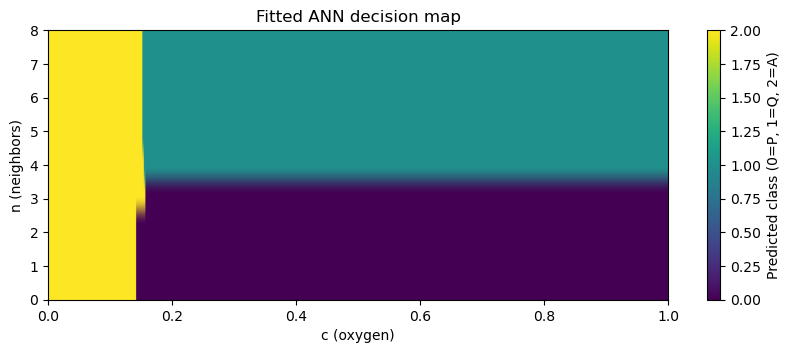

In [27]:
# --- Optional decision-map sanity check ---
import matplotlib.pyplot as plt

z_fit = logits_pqa(U_FIT, C, N)
pred_fit = np.argmax(z_fit, axis=1).reshape(N_grid.shape)

plt.figure(figsize=(10, 3.5))
plt.imshow(
    pred_fit,
    origin="lower",
    aspect="auto",
    extent=[C_MIN, C_MAX, N_MIN, N_MAX],
)
plt.colorbar(label="Predicted class (0=P, 1=Q, 2=A)")
plt.xlabel("c (oxygen)")
plt.ylabel("n (neighbors)")
plt.title("Fitted ANN decision map")
plt.show()
